<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     object 
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.4+ KB


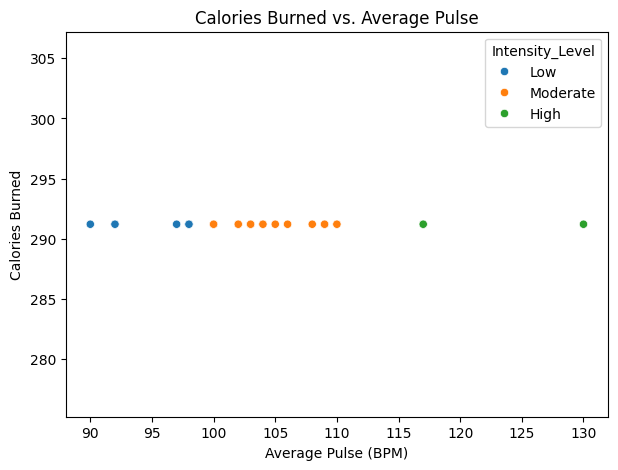

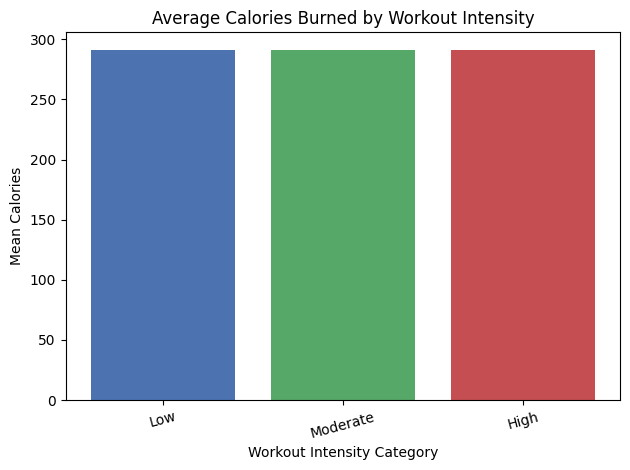

In [277]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

df.info()

df.describe()

df["Date"] = df["Date"].astype(str).str.replace("'"," ", regex = True).str.replace("nan","2020/12/22")
df["Date"] = df["Date"].str.replace("20201226","2020/12/26", regex=True)
df["Date"] = pd.to_datetime(df["Date"], errors = "coerce")

df["Calories"] = df["Calories"].fillna(df["Calories"]).median()

df.duplicated().sum()
df = df.drop_duplicates()

df[df["Date"] == '2020/12/20']
df[df["Duration"] == 450]
df[df["Pulse"] == 100]
df.loc[df["Maxpulse"] < 110]

data_type = df.copy()
type_data = pd.DataFrame(data_type)

merge_df = pd.merge(df, type_data, how="left", on="Duration")

df['Intensity_Level'] = df['Pulse'].apply(categorize_intensity)

fig, axes = plt.subplots(1, figsize=(7,5))
sns.scatterplot(ax=axes, data=df, x="Pulse", y="Calories", hue="Intensity_Level", hue_order=['Low', 'Moderate', 'High'])
axes.set_title('Calories Burned vs. Average Pulse')
axes.set_xlabel('Average Pulse (BPM)')
axes.set_ylabel('Calories Burned')
plt.savefig('Calories Burned vs. Average Pulse.png')
plt.show()

avg_calories = df.groupby('Intensity_Level')['Calories'].mean().reindex(['Low', 'Moderate', 'High']).reset_index()
plt.bar(avg_calories['Intensity_Level'], avg_calories['Calories'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Average Calories Burned by Workout Intensity')
plt.xlabel('Workout Intensity Category')
plt.ylabel('Mean Calories')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('Average Calories Burned by Workout Intensity.png')
plt.show()

